# Reconnaissance faciale pour la vérification d'identité
### Comparaison FaceNet vs ArcFace — Dataset LFW

**Objectif** : implémenter deux approches de deep learning pour la vérification d'identité et les comparer sur LFW selon les métriques FAR, FRR et AUC-ROC.

## Étape 1 — Installation des bibliothèques

In [1]:
!pip install facenet-pytorch deepface tf-keras -q

## Étape 2 — Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_pairs
from sklearn.metrics import roc_curve, auc
from PIL import Image
import torch
import cv2
import warnings
warnings.filterwarnings('ignore')

print('Imports OK')
print(f'GPU disponible : {torch.cuda.is_available()}')

Imports OK
GPU disponible : False


## Étape 3 — Chargement du dataset LFW

  
label : 1 = même personne, 0 = personnes différentes.

In [3]:
lfw = fetch_lfw_pairs(subset='test', color=True, resize=1.0)

images = lfw.pairs
labels = lfw.target

print(f'Nombre total de paires  : {len(labels)}')
print(f'Paires genuines         : {labels.sum()}')
print(f'Paires imposteurs       : {(labels==0).sum()}')
print(f'Taille des images       : {images.shape[2]}x{images.shape[3]} pixels')

Nombre total de paires  : 1000
Paires genuines         : 500
Paires imposteurs       : 500
Taille des images       : 125x94 pixels


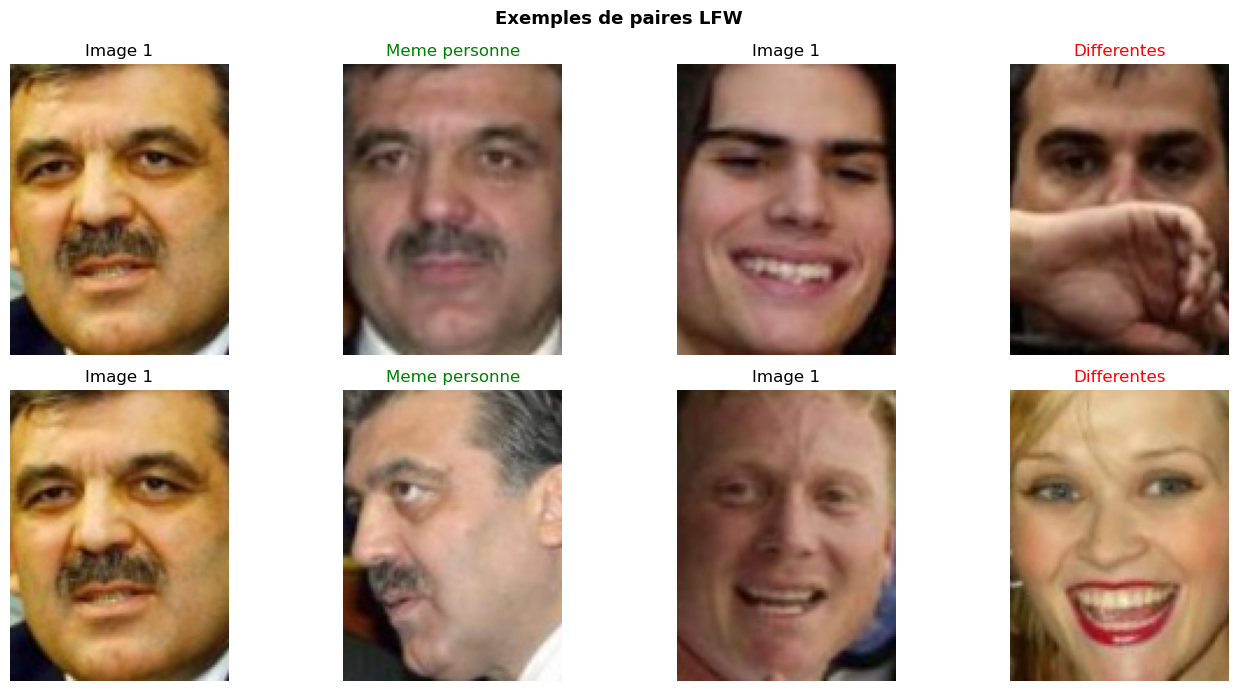

In [4]:
# Affichage de quelques paires
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Exemples de paires LFW', fontsize=13, fontweight='bold')

for i in range(2):
    idx = np.where(labels == 1)[0][i]
    axes[i][0].imshow((images[idx][0]*255).astype(np.uint8))
    axes[i][0].axis('off'); axes[i][0].set_title('Image 1')
    axes[i][1].imshow((images[idx][1]*255).astype(np.uint8))
    axes[i][1].axis('off'); axes[i][1].set_title('Meme personne', color='green')

    idx = np.where(labels == 0)[0][i]
    axes[i][2].imshow((images[idx][0]*255).astype(np.uint8))
    axes[i][2].axis('off'); axes[i][2].set_title('Image 1')
    axes[i][3].imshow((images[idx][1]*255).astype(np.uint8))
    axes[i][3].axis('off'); axes[i][3].set_title('Differentes', color='red')

plt.tight_layout()
plt.show()

In [5]:
# Sous-ensemble equlibre : 100 genuines + 100 imposteurs
np.random.seed(42)
idx_gen = np.where(labels == 1)[0]
idx_imp = np.where(labels == 0)[0]
sel = np.concatenate([np.random.choice(idx_gen, 100, replace=False),
                      np.random.choice(idx_imp, 100, replace=False)])
np.random.shuffle(sel)

pairs_test  = images[sel]
labels_test = labels[sel]
print(f'Sous-ensemble : {len(sel)} paires')

Sous-ensemble : 200 paires


## Étape 4 — Modèle 1 : FaceNet



In [6]:
from facenet_pytorch import InceptionResnetV1, MTCNN

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Detecteur MTCNN : aligne et recadre le visage
mtcnn = MTCNN(image_size=160, margin=14, device=device, keep_all=False)

# Reseau FaceNet pre-entraine sur VGGFace2
facenet = InceptionResnetV1(pretrained='vggface2').eval().to(device)

print('FaceNet charge !')

FaceNet charge !


In [7]:
def get_embedding_facenet(img_array):
    """
    Calcule l'embedding FaceNet.
    Entree : tableau numpy (H, W, 3) float [0,1]
    Sortie : vecteur numpy 512D normalise, ou None si pas de visage
    """
    img_pil = Image.fromarray((img_array * 255).astype(np.uint8))
    face = mtcnn(img_pil)
    if face is None:
        return None
    face = face.unsqueeze(0).to(device)
    with torch.no_grad():
        emb = facenet(face)
    emb = emb / emb.norm(p=2, dim=1, keepdim=True)
    return emb.cpu().numpy().flatten()


def similarite_cosinus(emb1, emb2):
    """Similarite cosinus entre deux embeddings"""
    return float(np.dot(emb1, emb2))

In [8]:
scores_facenet = []
erreurs_fn = 0

for i, (img1, img2) in enumerate(pairs_test):
    if i % 20 == 0:
        print(f'FaceNet — paire {i+1}/200', end='\r')
    emb1 = get_embedding_facenet(img1)
    emb2 = get_embedding_facenet(img2)
    if emb1 is None or emb2 is None:
        scores_facenet.append(0.0)
        erreurs_fn += 1
    else:
        scores_facenet.append(similarite_cosinus(emb1, emb2))

scores_facenet = np.array(scores_facenet)
print(f'\nFaceNet termine — erreurs : {erreurs_fn}/200')

FaceNet — paire 181/200
FaceNet termine — erreurs : 8/200


## Étape 5 — Modèle 2 : ArcFace


In [62]:
# ArcFace via DeepFace avec détecteur 'skip' 
# (on fait la détection nous-mêmes avec MTCNN déjà chargé)

def get_embedding_arcface(img_array):
    """
    ArcFace avec détecteur skip - utilise MTCNN pour la détection
    et DeepFace uniquement pour l'embedding ArcFace
    """
    # D'abord on détecte le visage avec MTCNN (déjà fonctionnel)
    img_pil = Image.fromarray((img_array * 255).astype(np.uint8))
    face = mtcnn(img_pil)
    if face is None:
        return None
    
    # On reconvertit en numpy pour DeepFace
    face_np = face.permute(1, 2, 0).numpy()
    face_np = ((face_np + 1) / 2 * 255).clip(0, 255).astype(np.uint8)
    face_bgr = cv2.cvtColor(face_np, cv2.COLOR_RGB2BGR)

    try:
        result = DeepFace.represent(
            img_path=face_bgr,
            model_name='ArcFace',
            detector_backend='skip',  # skip = pas de détection, visage déjà cropé
            enforce_detection=False,
            align=False
        )
        emb = np.array(result[0]['embedding'])
        emb = emb / (np.linalg.norm(emb) + 1e-8)
        return emb
    except:
        return None

In [96]:
scores_arcface = []
erreurs_arc = 0

for i, (img1, img2) in enumerate(pairs_test):
    if i % 20 == 0:
        print(f'ArcFace — paire {i+1}/200', end='\r')
    emb1 = get_embedding_arcface(img1)
    emb2 = get_embedding_arcface(img2)
    if emb1 is None or emb2 is None:
        scores_arcface.append(0.0)
        erreurs_arc += 1
    else:
        scores_arcface.append(similarite_cosinus(emb1, emb2))

scores_arcface = np.array(scores_arcface)
print(f'\nArcFace termine — erreurs : {erreurs_arc}/200')

ArcFace — paire 181/200
ArcFace termine — erreurs : 8/200


## Étape 6 — Calcul des métriques : FAR, FRR, EER, AUC

In [97]:
def calculer_far_frr(scores, labels, seuils):
    scores_gen = scores[labels == 1]
    scores_imp = scores[labels == 0]
    far = np.array([np.mean(scores_imp >= t) for t in seuils])
    frr = np.array([np.mean(scores_gen <  t) for t in seuils])
    return far, frr

def calculer_eer(far, frr, seuils):
    idx = np.argmin(np.abs(far - frr))
    return (far[idx] + frr[idx]) / 2.0, seuils[idx]

seuils = np.linspace(-0.2, 1.0, 500)

far_fn,  frr_fn  = calculer_far_frr(scores_facenet, labels_test, seuils)
eer_fn,  s_fn    = calculer_eer(far_fn,  frr_fn,  seuils)
fpr_fn,  tpr_fn, _ = roc_curve(labels_test, scores_facenet)
auc_fn = auc(fpr_fn, tpr_fn)

far_arc, frr_arc = calculer_far_frr(scores_arcface, labels_test, seuils)
eer_arc, s_arc   = calculer_eer(far_arc, frr_arc, seuils)
fpr_arc, tpr_arc, _ = roc_curve(labels_test, scores_arcface)
auc_arc = auc(fpr_arc, tpr_arc)

print('='*50)
print(f'{"Modele":<22} {"EER":>8} {"AUC":>8} {"Seuil EER":>10}')
print('-'*50)
print(f'{"FaceNet (VGGFace2)":<22} {eer_fn*100:>7.2f}% {auc_fn:>8.4f} {s_fn:>10.4f}')
print(f'{"ArcFace (ResNet50)":<22} {eer_arc*100:>7.2f}% {auc_arc:>8.4f} {s_arc:>10.4f}')
print('='*50)

Modele                      EER      AUC  Seuil EER
--------------------------------------------------
FaceNet (VGGFace2)        2.00%   0.9877     0.4012
ArcFace (ResNet50)        8.00%   0.9583     0.3315


## Étape 7 — Visualisation des résultats

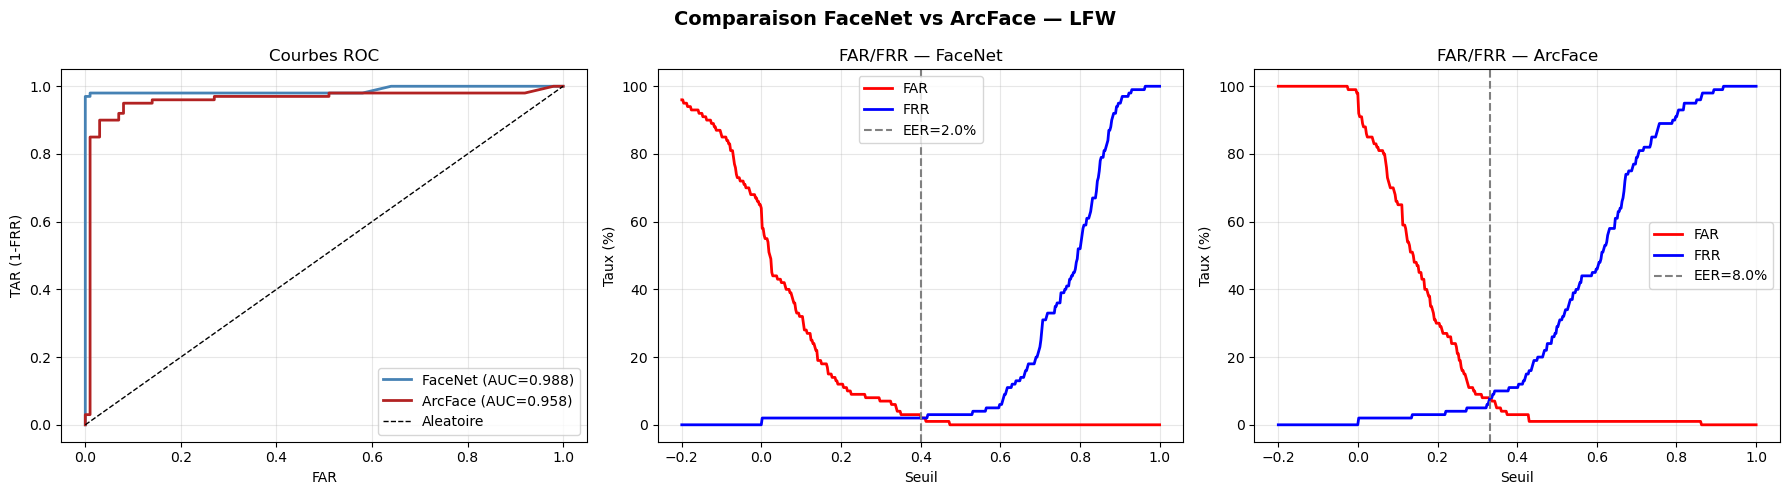

In [98]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparaison FaceNet vs ArcFace — LFW', fontsize=14, fontweight='bold')

# Courbes ROC
ax = axes[0]
ax.plot(fpr_fn,  tpr_fn,  color='steelblue', lw=2, label=f'FaceNet (AUC={auc_fn:.3f})')
ax.plot(fpr_arc, tpr_arc, color='firebrick', lw=2, label=f'ArcFace (AUC={auc_arc:.3f})')
ax.plot([0,1],[0,1],'k--',lw=1,label='Aleatoire')
ax.set_xlabel('FAR'); ax.set_ylabel('TAR (1-FRR)')
ax.set_title('Courbes ROC'); ax.legend(); ax.grid(alpha=0.3)

# FAR/FRR FaceNet
ax = axes[1]
ax.plot(seuils, far_fn*100, 'r', lw=2, label='FAR')
ax.plot(seuils, frr_fn*100, 'b', lw=2, label='FRR')
ax.axvline(x=s_fn, color='gray', linestyle='--', lw=1.5, label=f'EER={eer_fn*100:.1f}%')
ax.set_xlabel('Seuil'); ax.set_ylabel('Taux (%)')
ax.set_title('FAR/FRR — FaceNet'); ax.legend(); ax.grid(alpha=0.3)

# FAR/FRR ArcFace
ax = axes[2]
ax.plot(seuils, far_arc*100, 'r', lw=2, label='FAR')
ax.plot(seuils, frr_arc*100, 'b', lw=2, label='FRR')
ax.axvline(x=s_arc, color='gray', linestyle='--', lw=1.5, label=f'EER={eer_arc*100:.1f}%')
ax.set_xlabel('Seuil'); ax.set_ylabel('Taux (%)')
ax.set_title('FAR/FRR — ArcFace'); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation_results.png', dpi=150, bbox_inches='tight')
plt.show()

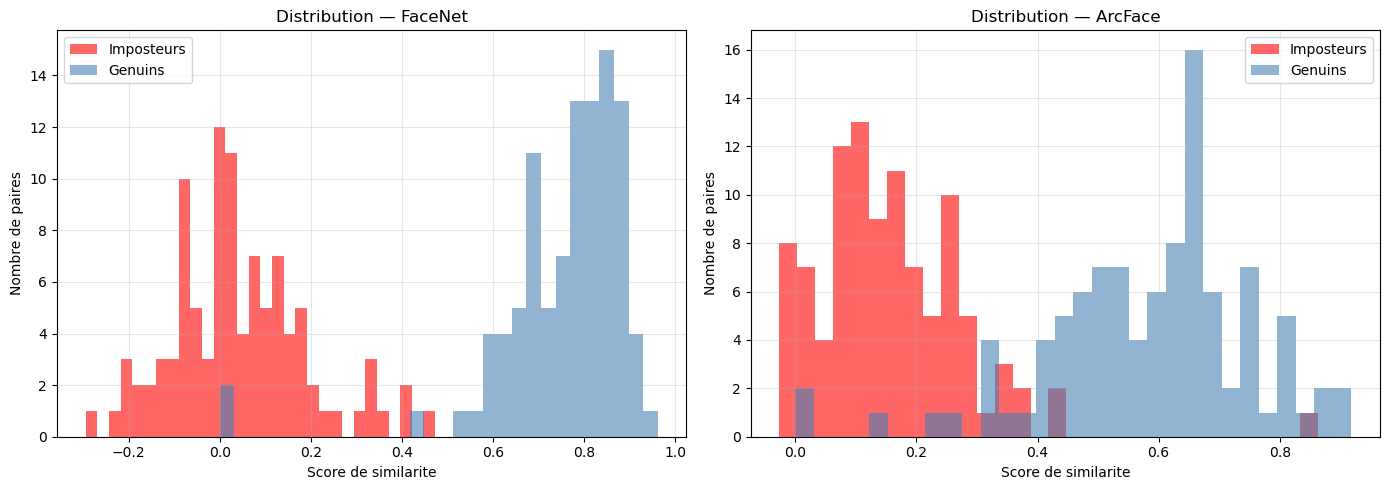

In [99]:
# Distribution des scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, scores, titre in zip(axes, [scores_facenet, scores_arcface], ['FaceNet','ArcFace']):
    ax.hist(scores[labels_test==0], bins=30, alpha=0.6, color='red',       label='Imposteurs')
    ax.hist(scores[labels_test==1], bins=30, alpha=0.6, color='steelblue', label='Genuins')
    ax.set_xlabel('Score de similarite'); ax.set_ylabel('Nombre de paires')
    ax.set_title(f'Distribution — {titre}'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Étape 9 — Résumé final

In [106]:
print('='*50)
print('  RESULTATS FINAUX')
print('='*50)
print(f'{"Modele":<25} {"EER":>8} {"AUC":>8}')
print('-'*50)
print(f'{"FaceNet (VGGFace2)":<25} {eer_fn*100:>7.2f}% {auc_fn:>8.4f}')
print(f'{"ArcFace (MS-Celeb-1M)":<25} {eer_arc*100:>7.2f}% {auc_arc:>8.4f}')
print('='*50)
print(f'Meilleur modele : {"ArcFace" if eer_arc < eer_fn else "FaceNet"}')

  RESULTATS FINAUX
Modele                         EER      AUC
--------------------------------------------------
FaceNet (VGGFace2)           2.00%   0.9877
ArcFace (MS-Celeb-1M)        8.00%   0.9583
Meilleur modele : FaceNet
